# Sarcasm Detection with GloVe Embeddings
### 4 Models: With/Without Attention × With/Without Parent Comment

**Models:**
1. `Model 1` — Parent + Comment, **No Attention** (BiLSTM)
2. `Model 2` — Parent + Comment, **With Attention** (BiLSTM + Attention)
3. `Model 3` — Comment Only, **No Attention** (BiLSTM)
4. `Model 4` — Comment Only, **With Attention** (BiLSTM + Attention)

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense,
    Dropout, Concatenate, GlobalMaxPooling1D,
    Layer, Multiply, Softmax, Lambda
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH     = "/kaggle/input/datasets/sahilakolte/nlp-sarcasm-detection"
GLOVE_PATH    = os.path.join(BASE_PATH, "glove.6B.300d.txt")
TRAIN_PATH    = os.path.join(BASE_PATH, "train-balanced-sarcasm.csv")
TEST_PATH     = os.path.join(BASE_PATH, "test-balanced.csv")
OUTPUT_DIR    = "/kaggle/working/"

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-04-17 09:07:57.772962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776416877.947384      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776416878.005199      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776416878.442997      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776416878.443038      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776416878.443041      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Hyperparameters

In [2]:
# ── Tuneable config ──────────────────────────────────────────────────────────
MAX_VOCAB      = 80_000   
MAX_LEN        = 100      
EMBED_DIM      = 300      
LSTM_UNITS     = 128      
DROPOUT        = 0.3
DENSE_UNITS    = 64
BATCH_SIZE     = 256
EPOCHS         = 20       
VAL_SPLIT      = 0.1      
LR             = 1e-3
PATIENCE       = 3        
# ─────────────────────────────────────────────────────────────────────────────
print("Config loaded.")

Config loaded.


## 3. Load & Explore Data

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH, sep=None, engine='python')

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
train_df.head(3)

Train shape: (1010826, 10)
Test  shape: (251608, 10)

Train columns: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.


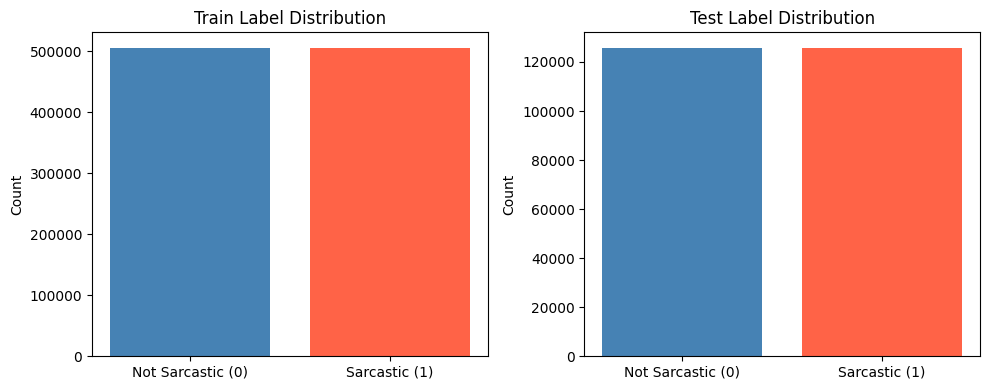

In [5]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Test", test_df)]):
    counts = df['label'].value_counts()
    ax.bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values,
           color=['steelblue', 'tomato'])
    ax.set_title(f"{name} Label Distribution")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution.png"), dpi=120)
plt.show()

## 4. Text Preprocessing

In [6]:
import re
import string

def clean_text(text):
    """Lowercase, strip URLs, punctuation, extra spaces."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)            # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # collapse spaces
    return text

for df in [train_df, test_df]:
    df['comment_clean']        = df['comment'].apply(clean_text)
    df['parent_comment_clean'] = df['parent_comment'].apply(clean_text)

print("Cleaning done.")
print("Sample comment:", train_df['comment_clean'].iloc[0])
print("Sample parent :", train_df['parent_comment_clean'].iloc[0])

Cleaning done.
Sample comment: nc and nh
Sample parent : yeah i get that argument at this point i d prefer is she lived in nc as well


In [7]:
all_train_texts = (
    train_df['comment_clean'].tolist() +
    train_df['parent_comment_clean'].tolist()
)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(all_train_texts)

# Save tokenizer for later reproduction
with open(os.path.join(OUTPUT_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index)) + 1
print(f"Vocabulary size (capped): {VOCAB_SIZE}")

def texts_to_padded(texts, maxlen=MAX_LEN):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

# Encode & pad
X_comment_train = texts_to_padded(train_df['comment_clean'])
X_parent_train  = texts_to_padded(train_df['parent_comment_clean'])
X_comment_test  = texts_to_padded(test_df['comment_clean'])
X_parent_test   = texts_to_padded(test_df['parent_comment_clean'])

y_train = train_df['label'].values
y_test  = test_df['label'].values

print("X_comment_train:", X_comment_train.shape)
print("X_parent_train :", X_parent_train.shape)

Vocabulary size (capped): 80001
X_comment_train: (1010826, 100)
X_parent_train : (1010826, 100)


In [8]:
# Train / Validation split
(
 X_com_tr, X_com_val,
 X_par_tr, X_par_val,
 y_tr,     y_val
) = train_test_split(
    X_comment_train, X_parent_train, y_train,
    test_size=VAL_SPLIT, random_state=SEED, stratify=y_train
)

print(f"Train: {X_com_tr.shape[0]} | Val: {X_com_val.shape[0]} | Test: {X_comment_test.shape[0]}")

Train: 909743 | Val: 101083 | Test: 251608


## 5. GloVe Embedding Matrix

In [14]:
def load_glove(path, embed_dim):
    embeddings = {}
    bad_lines = 0

    with open(path, encoding='utf-8') as f:
        for i, line in enumerate(f):
            parts = line.strip().split()

            # skip empty or malformed lines
            if len(parts) <= embed_dim:
                bad_lines += 1
                continue

            word = parts[0]

            try:
                vec = np.array(parts[1:], dtype='float32')

                # ensure correct dimension
                if vec.shape[0] != embed_dim:
                    bad_lines += 1
                    continue

                embeddings[word] = vec

            except ValueError:
                bad_lines += 1
                continue

    print(f"Loaded {len(embeddings):,} GloVe vectors.")
    print(f"Skipped {bad_lines:,} bad lines.")
    return embeddings

glove = load_glove(GLOVE_PATH, EMBED_DIM)

def build_embedding_matrix(tokenizer, glove, vocab_size, embed_dim):
    matrix = np.zeros((vocab_size, embed_dim))
    hits = 0

    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue

        vec = glove.get(word)
        if vec is not None:
            matrix[idx] = vec
            hits += 1

    print(f"Embedding hits: {hits:,} / {vocab_size:,} ({100*hits/vocab_size:.1f}%)")
    return matrix

embedding_matrix = build_embedding_matrix(
    tokenizer,
    glove,
    VOCAB_SIZE,
    EMBED_DIM
)

del glove

Loaded 1,287,614 GloVe vectors.
Skipped 3,533 bad lines.
Embedding hits: 71,746 / 80,001 (89.7%)


## 6. Custom Attention Layer

In [16]:
class BahdanauAttention(Layer):
    """
    Additive (Bahdanau) self-attention.
    Input : (batch, timesteps, features)
    Output: (batch, features)  — context vector
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W  = Dense(units, use_bias=False)
        self.V  = Dense(1,     use_bias=False)

    def call(self, hidden_states):
        # hidden_states: (batch, T, H)
        score  = self.V(tf.nn.tanh(self.W(hidden_states)))  # (batch, T, 1)
        alpha  = tf.nn.softmax(score, axis=1)               # (batch, T, 1)
        context = tf.reduce_sum(alpha * hidden_states, axis=1)  # (batch, H)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg

print("BahdanauAttention layer defined.")

BahdanauAttention layer defined.


## 7. Model Factory

In [18]:
embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name='glove_embedding'
)

def encode_sequence(inp, use_attention, prefix=''):
    x = embedding_layer(inp)
    x = Dropout(DROPOUT, name=f'{prefix}_emb_drop')(x)

    x = Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=True),
        name=f'{prefix}_bilstm'
    )(x)

    x = Dropout(DROPOUT, name=f'{prefix}_lstm_drop')(x)

    if use_attention:
        x = BahdanauAttention(units=LSTM_UNITS, name=f'{prefix}_attention')(x)
    else:
        x = GlobalMaxPooling1D(name=f'{prefix}_pool')(x)

    return x


def build_model(use_parent: bool, use_attention: bool, model_name: str):
    """
    Build and compile one of the 4 model variants.

    Parameters
    ----------
    use_parent    : include parent_comment branch
    use_attention : use Bahdanau attention instead of MaxPooling
    model_name    : string tag used in layer names
    """
    comment_inp = Input(shape=(MAX_LEN,), name='comment_input')
    comment_vec = encode_sequence(comment_inp, use_attention, prefix='com')

    if use_parent:
        parent_inp  = Input(shape=(MAX_LEN,), name='parent_input')
        parent_vec  = encode_sequence(parent_inp, use_attention, prefix='par')
        combined    = Concatenate(name='concat')([comment_vec, parent_vec])
        inputs      = [comment_inp, parent_inp]
    else:
        combined = comment_vec
        inputs   = [comment_inp]

    x = Dense(DENSE_UNITS, activation='relu', name='dense1')(combined)
    x = Dropout(DROPOUT, name='dense_drop')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=out, name=model_name)
    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


# Instantiate all 4 models
model_configs = {
    'model1_parent_comment_no_attn'  : dict(use_parent=True,  use_attention=False),
    'model2_parent_comment_attn'     : dict(use_parent=True,  use_attention=True),
    'model3_comment_only_no_attn'    : dict(use_parent=False, use_attention=False),
    'model4_comment_only_attn'       : dict(use_parent=False, use_attention=True),
}

models = {}
for name, cfg in model_configs.items():
    models[name] = build_model(model_name=name, **cfg)
    print(f"\n{'='*60}\n{name}")
    models[name].summary()

print("\nAll 4 models built successfully.")


model1_parent_comment_no_attn


Model: "model1_parent_comment_no_attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ comment_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ parent_input        │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 100, 300)  │ 24,000,300 │ comment_input[0]… │
│ (Embedding)         │                   │            │ parent_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ com_emb_drop        │ (None, 100, 300)  │          0 │ glove_embedding[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ par_emb_drop        │ (None, 100, 300)  │          0 │ glove_embedding[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ com_bilstm          │ (None, 100, 256)  │    439,296 │ com_emb_drop[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ par_bilstm          │ (None, 100, 256)  │    439,296 │ par_emb_drop[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ com_lstm_drop       │ (None, 100, 256)  │          0 │ com_bilstm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ par_lstm_drop       │ (None, 100, 256)  │          0 │ par_bilstm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ com_pool            │ (None, 256)       │          0 │ com_lstm_drop[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ par_pool            │ (None, 256)       │          0 │ par_lstm_drop[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ com_pool[0][0],   │
│ (Concatenate)       │                   │            │ par_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 64)        │     32,832 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_drop          │ (None, 64)        │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dense_drop[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,911,789 (95.03 MB)

 Trainable params: 911,489 (3.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ comment_input (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 100, 300)       │    24,000,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ com_emb_drop (Dropout)          │ (None, 100, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ com_bilstm (Bidirectional)      │ (None, 100, 256)       │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ com_lstm_drop (Dropout)         │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ com_attention                   │ (None, 256)            │        32,896 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_drop (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,489,005 (93.42 MB)

 Trainable params: 488,705 (1.86 MB)

 Non-trainable params: 24,000,300 (91.55 MB)


All 4 models built successfully.


## 8. Training Utilities

In [19]:
def get_inputs(X_comment, X_parent, use_parent):
    """Return the right input list depending on model variant."""
    if use_parent:
        return [X_comment, X_parent]
    return [X_comment]


def train_model(model, name, use_parent):
    ckpt_path = os.path.join(OUTPUT_DIR, f'{name}_best.keras')

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            ckpt_path, monitor='val_loss',
            save_best_only=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        )
    ]

    train_inputs = get_inputs(X_com_tr, X_par_tr, use_parent)
    val_inputs   = get_inputs(X_com_val, X_par_val, use_parent)

    history = model.fit(
        train_inputs, y_tr,
        validation_data=(val_inputs, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    print(f"\n✅ Best model saved → {ckpt_path}")
    return history


def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(name, fontsize=13)

    axes[0].plot(history.history['loss'],     label='train loss')
    axes[0].plot(history.history['val_loss'], label='val loss')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='train acc')
    axes[1].plot(history.history['val_accuracy'], label='val acc')
    axes[1].set_title('Accuracy'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_history.png'), dpi=120)
    plt.show()


def evaluate_model(model, name, use_parent):
    test_inputs = get_inputs(X_comment_test, X_parent_test, use_parent)
    y_prob = model.predict(test_inputs, batch_size=BATCH_SIZE, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Not Sarcastic', 'Sarcastic'])

    print(f"\n{'='*55}")
    print(f"  RESULTS — {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{report}")

    # Confusion matrix heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Sarc', 'Sarc'],
                yticklabels=['Not Sarc', 'Sarc'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_cm.png'), dpi=120)
    plt.show()

    return dict(name=name, accuracy=acc, f1=f1, auc=auc)


print("Utility functions ready.")

Utility functions ready.


## 9. Train Model 1 — Parent + Comment, No Attention

Epoch 1/20


I0000 00:00:1776418693.115402     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


3554/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6637 - auc: 0.7250 - loss: 0.6059 - precision: 0.6808 - recall: 0.6199
Epoch 1: val_loss improved from inf to 0.54827, saving model to /kaggle/working/model1_parent_comment_no_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 309s 85ms/step - accuracy: 0.6637 - auc: 0.7250 - loss: 0.6059 - precision: 0.6808 - recall: 0.6199 - val_accuracy: 0.7168 - val_auc: 0.7950 - val_loss: 0.5483 - val_precision: 0.7667 - val_recall: 0.6231 - learning_rate: 0.0010
Epoch 2/20
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7141 - auc: 0.7879 - loss: 0.5524 - precision: 0.7384 - recall: 0.6634
Epoch 2: val_loss improved from 0.54827 to 0.53226, saving model to /kaggle/working/model1_parent_comment_no_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 300s 84ms/step - accuracy: 0.7141 - auc: 0.7879 - loss: 0.5524 - precision: 0.7384 - recall: 0.6634 - val_accuracy: 0.7309 - val_auc: 0.8100 - val_loss: 0.5323 - val_precision: 0.7666 - val_reca

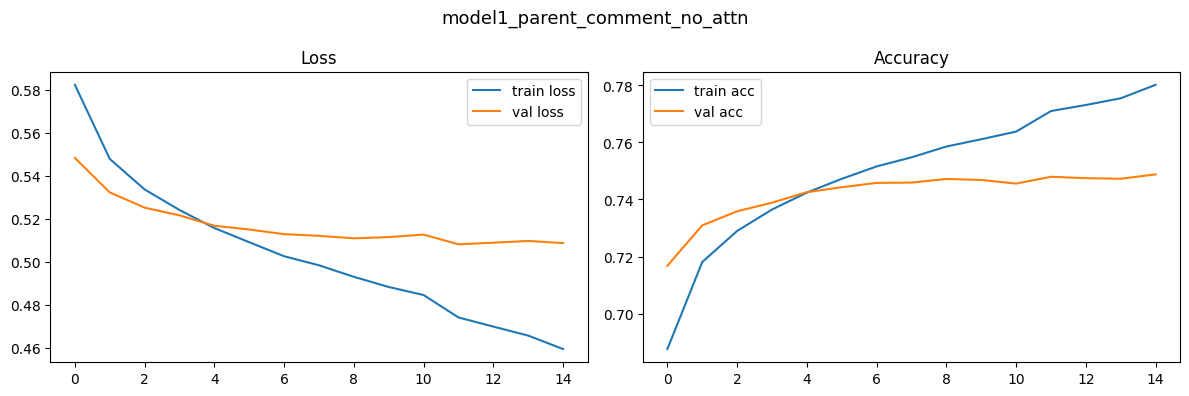

In [20]:
name1 = 'model1_parent_comment_no_attn'
hist1 = train_model(models[name1], name1, use_parent=True)
plot_history(hist1, name1)

## 10. Train Model 2 — Parent + Comment, With Attention

Epoch 1/20
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6552 - auc: 0.7162 - loss: 0.6106 - precision: 0.6730 - recall: 0.6074
Epoch 1: val_loss improved from inf to 0.54377, saving model to /kaggle/working/model2_parent_comment_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 329s 91ms/step - accuracy: 0.6552 - auc: 0.7162 - loss: 0.6106 - precision: 0.6730 - recall: 0.6074 - val_accuracy: 0.7213 - val_auc: 0.7962 - val_loss: 0.5438 - val_precision: 0.7358 - val_recall: 0.6905 - learning_rate: 0.0010
Epoch 2/20
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7170 - auc: 0.7913 - loss: 0.5487 - precision: 0.7398 - recall: 0.6700
Epoch 2: val_loss improved from 0.54377 to 0.52916, saving model to /kaggle/working/model2_parent_comment_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 323s 91ms/step - accuracy: 0.7170 - auc: 0.7913 - loss: 0.5486 - precision: 0.7398 - recall: 0.6700 - val_accuracy: 0.7328 - val_auc: 0.8106 - val_loss: 0.5292 - val_precision: 0.7401 - val

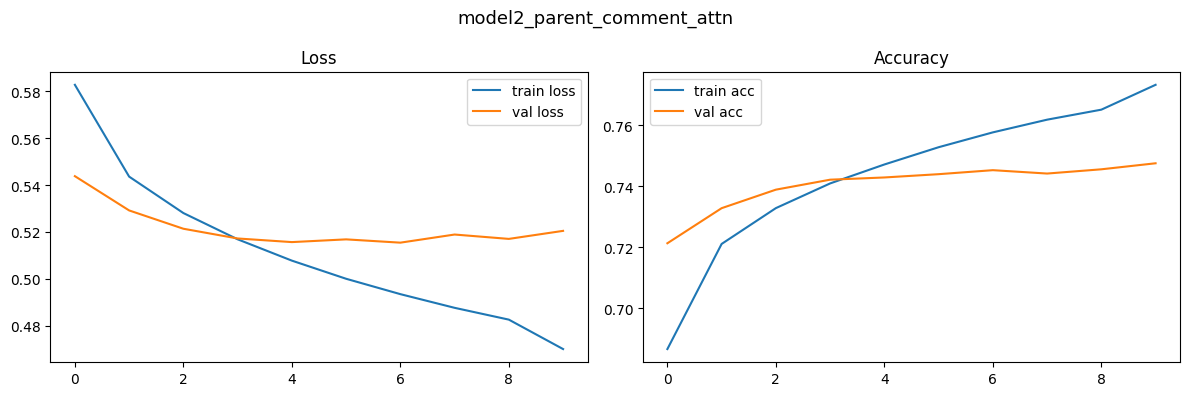

In [21]:
name2 = 'model2_parent_comment_attn'
hist2 = train_model(models[name2], name2, use_parent=True)
plot_history(hist2, name2)

## 11. Train Model 3 — Comment Only, No Attention

Epoch 1/20
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7663 - auc: 0.8486 - loss: 0.4795 - precision: 0.7869 - recall: 0.7307
Epoch 1: val_loss improved from inf to 0.51544, saving model to /kaggle/working/model3_comment_only_no_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 151s 42ms/step - accuracy: 0.7663 - auc: 0.8486 - loss: 0.4794 - precision: 0.7869 - recall: 0.7307 - val_accuracy: 0.7421 - val_auc: 0.8210 - val_loss: 0.5154 - val_precision: 0.7545 - val_recall: 0.7176 - learning_rate: 2.5000e-04
Epoch 2/20
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7677 - auc: 0.8495 - loss: 0.4784 - precision: 0.7865 - recall: 0.7351
Epoch 2: val_loss did not improve from 0.51544
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 150s 42ms/step - accuracy: 0.7677 - auc: 0.8495 - loss: 0.4784 - precision: 0.7865 - recall: 0.7351 - val_accuracy: 0.7420 - val_auc: 0.8208 - val_loss: 0.5157 - val_precision: 0.7526 - val_recall: 0.7209 - learning_rate: 2.5000e-04
Epoch 3/20
3553/3554 ━━━━━

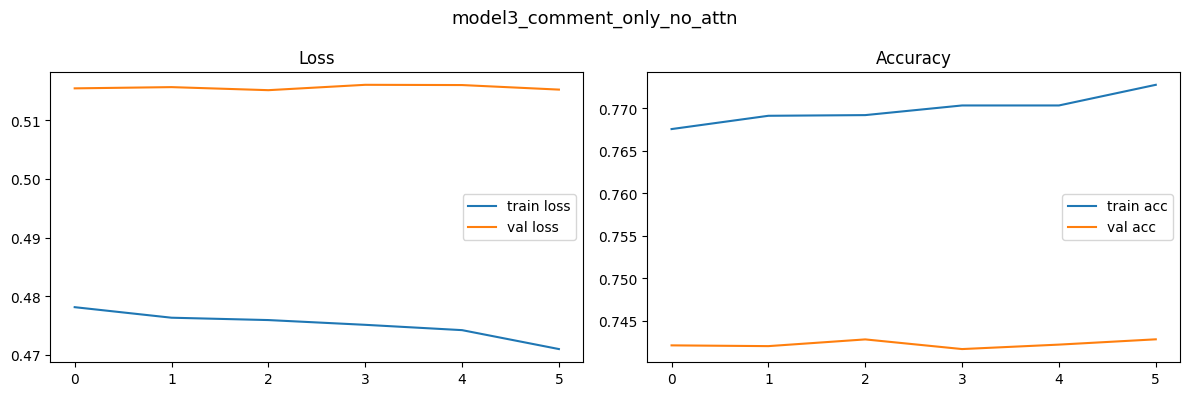

In [23]:
name3 = 'model3_comment_only_no_attn'
hist3 = train_model(models[name3], name3, use_parent=False)
plot_history(hist3, name3)

## 12. Train Model 4 — Comment Only, With Attention

Epoch 1/20
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6607 - auc: 0.7209 - loss: 0.6089 - precision: 0.6817 - recall: 0.6074
Epoch 1: val_loss improved from inf to 0.55248, saving model to /kaggle/working/model4_comment_only_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 167s 46ms/step - accuracy: 0.6608 - auc: 0.7209 - loss: 0.6088 - precision: 0.6817 - recall: 0.6074 - val_accuracy: 0.7142 - val_auc: 0.7877 - val_loss: 0.5525 - val_precision: 0.7293 - val_recall: 0.6812 - learning_rate: 0.0010
Epoch 2/20
3553/3554 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7103 - auc: 0.7815 - loss: 0.5581 - precision: 0.7366 - recall: 0.6550
Epoch 2: val_loss improved from 0.55248 to 0.53879, saving model to /kaggle/working/model4_comment_only_attn_best.keras
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 164s 46ms/step - accuracy: 0.7103 - auc: 0.7815 - loss: 0.5581 - precision: 0.7366 - recall: 0.6550 - val_accuracy: 0.7242 - val_auc: 0.8015 - val_loss: 0.5388 - val_precision: 0.7334 - val_rec

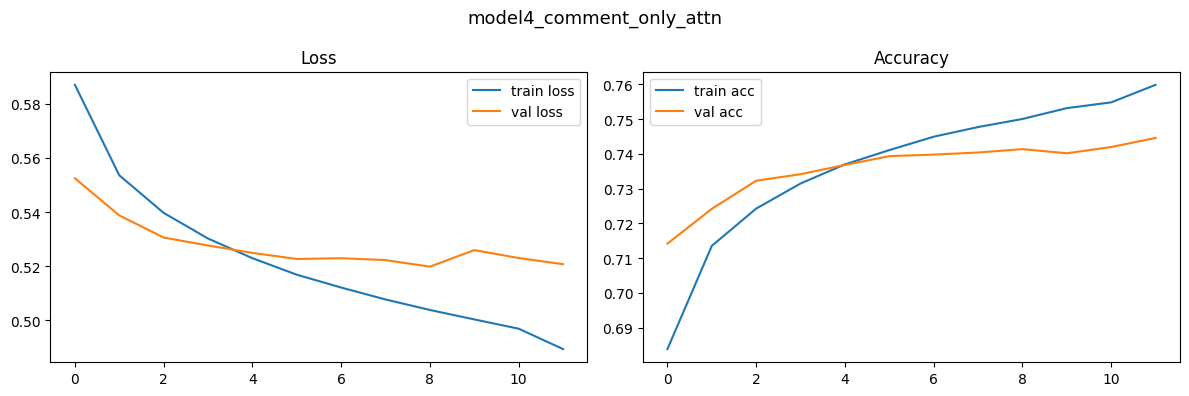

In [24]:
name4 = 'model4_comment_only_attn'
hist4 = train_model(models[name4], name4, use_parent=False)
plot_history(hist4, name4)

## 13. Evaluate All Models on Test Set


  RESULTS — model1_parent_comment_no_attn
  Accuracy : 0.7466
  F1-Score : 0.7422
  ROC-AUC  : 0.8259

               precision    recall  f1-score   support

Not Sarcastic       0.74      0.76      0.75    125804
    Sarcastic       0.76      0.73      0.74    125804

     accuracy                           0.75    251608
    macro avg       0.75      0.75      0.75    251608
 weighted avg       0.75      0.75      0.75    251608



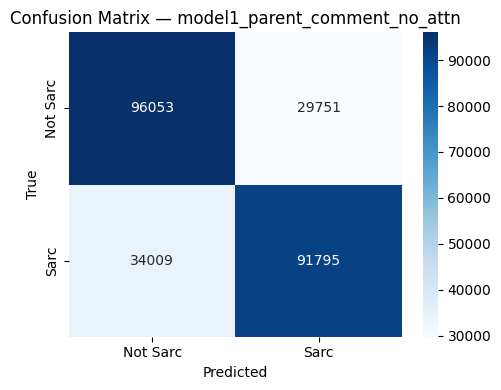

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'com_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'par_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



  RESULTS — model2_parent_comment_attn
  Accuracy : 0.7445
  F1-Score : 0.7454
  ROC-AUC  : 0.8247

               precision    recall  f1-score   support

Not Sarcastic       0.75      0.74      0.74    125804
    Sarcastic       0.74      0.75      0.75    125804

     accuracy                           0.74    251608
    macro avg       0.74      0.74      0.74    251608
 weighted avg       0.74      0.74      0.74    251608



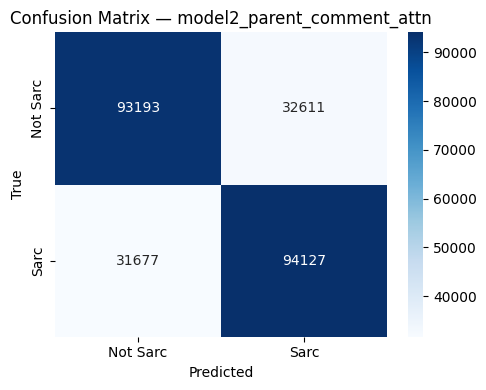


  RESULTS — model3_comment_only_no_attn
  Accuracy : 0.7413
  F1-Score : 0.7355
  ROC-AUC  : 0.8200

               precision    recall  f1-score   support

Not Sarcastic       0.73      0.76      0.75    125804
    Sarcastic       0.75      0.72      0.74    125804

     accuracy                           0.74    251608
    macro avg       0.74      0.74      0.74    251608
 weighted avg       0.74      0.74      0.74    251608



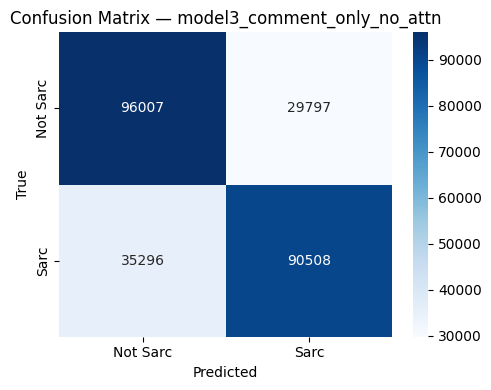

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'com_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



  RESULTS — model4_comment_only_attn
  Accuracy : 0.7395
  F1-Score : 0.7358
  ROC-AUC  : 0.8187

               precision    recall  f1-score   support

Not Sarcastic       0.73      0.75      0.74    125804
    Sarcastic       0.75      0.73      0.74    125804

     accuracy                           0.74    251608
    macro avg       0.74      0.74      0.74    251608
 weighted avg       0.74      0.74      0.74    251608



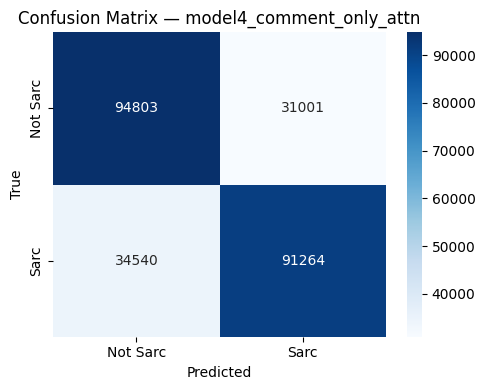


FINAL COMPARISON TABLE
                               accuracy      f1     auc
name                                                   
model1_parent_comment_no_attn    0.7466  0.7422  0.8259
model2_parent_comment_attn       0.7445  0.7454  0.8247
model3_comment_only_no_attn      0.7413  0.7355  0.8200
model4_comment_only_attn         0.7395  0.7358  0.8187


In [25]:
custom_objs = {'BahdanauAttention': BahdanauAttention}

results = []
eval_map = [
    (name1, True),
    (name2, True),
    (name3, False),
    (name4, False),
]

for name, use_parent in eval_map:
    # Reload from checkpoint to guarantee we use the best weights
    ckpt = os.path.join(OUTPUT_DIR, f'{name}_best.keras')
    model = load_model(ckpt, custom_objects=custom_objs)
    res = evaluate_model(model, name, use_parent)
    results.append(res)

results_df = pd.DataFrame(results).set_index('name')
print("\n" + "="*55)
print("FINAL COMPARISON TABLE")
print("="*55)
print(results_df.round(4).to_string())

## 14. Side-by-Side Bar Chart Comparison

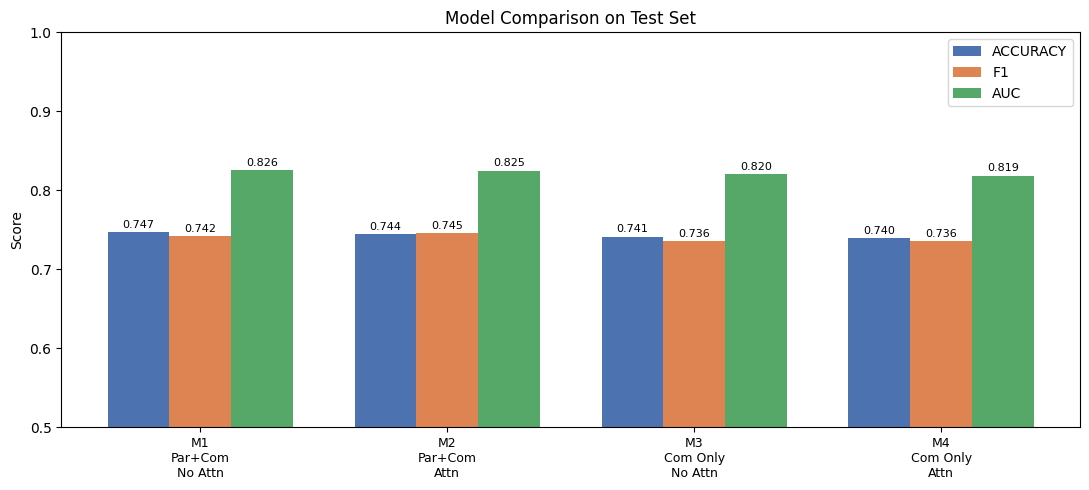

results_summary.csv saved.


In [26]:
metrics = ['accuracy', 'f1', 'auc']
short_names = ['M1\nPar+Com\nNo Attn', 'M2\nPar+Com\nAttn',
               'M3\nCom Only\nNo Attn', 'M4\nCom Only\nAttn']

x     = np.arange(len(short_names))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric.upper(), color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150)
plt.show()

# Save results CSV
results_df.to_csv(os.path.join(OUTPUT_DIR, 'results_summary.csv'))
print("results_summary.csv saved.")